# Seasonal Agriculture Performance Analysis

**VOIS–AICTE Batch 1 (2026–2027) — Major Project**

---

## 1. Project Overview

Agricultural activities are deeply influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market dynamics. Different seasons bring distinct weather patterns, resource constraints, and crop-growing conditions that together shape agricultural outcomes.

This project analyzes a dataset of 4,000 farm-level observations across three Indian agricultural seasons — **Kharif** (monsoon), **Rabi** (winter), and **Zaid** (summer) — to investigate how agricultural performance varies across seasons and what factors are associated with those differences.

The analysis follows a logical chain:

**Season → Environmental Conditions → Resource Usage → Agricultural Performance → Economic Outcomes**

## 2. Problem Statement

Agricultural performance may differ from one season to another due to variations in rainfall, temperature, humidity, soil conditions, resource inputs, and market prices. The objective is to analyze the agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations.

## 3. Objectives

1. Understand how agricultural yield and production vary across Kharif, Rabi, and Zaid seasons.
2. Investigate seasonal differences in environmental conditions (rainfall, temperature, humidity, soil).
3. Analyze how resource usage (water, fertilizer, pesticide) differs by season.
4. Examine economic performance (revenue, cost, profit) across seasons.
5. Explore crop-specific and region-specific seasonal patterns.
6. Identify the strongest relationships between seasonal factors and agricultural outcomes.
7. Provide evidence-based recommendations for seasonal agricultural planning.

## 4. Research Questions

Based on an initial exploration of the dataset, the following questions guide this analysis:

1. **How does agricultural yield vary across Kharif, Rabi, and Zaid seasons?**
2. **How do environmental conditions (rainfall, temperature, humidity) differ across seasons?**
3. **How does resource usage (water, fertilizer, pesticide) differ across seasons?**
4. **Which season delivers the best economic performance (revenue, profit)?**
5. **Are environmental factors (rainfall, temperature) associated with yield and production?**
6. **Does resource usage (fertilizer, water) show a relationship with yield?**
7. **Do seasonal performance patterns vary between different crops?**
8. **Do seasonal performance patterns vary across states/regions?**
9. **Which factors show the strongest association with agricultural performance?**
10. **Are there unusual or unexpected seasonal patterns in the data?**

## 5. Dataset Description

**Source:** `seasonal_agriculture_performance_dataset.csv`  
**Size:** 4,000 rows × 28 columns  
**Scope:** Farm-level agricultural observations across 8 Indian states, 10 districts, 8 crops, and 3 seasons.

### Data Dictionary

| Column | Meaning | Data Type | Role |
|--------|---------|-----------|------|
| Farm_ID | Unique farm identifier | Categorical (ID) | Identifier |
| State | Indian state name | Categorical | Geographic |
| District | District within state | Categorical | Geographic |
| Crop | Crop grown | Categorical | Crop classification |
| Season | Agricultural season (Kharif/Rabi/Zaid) | Categorical | **Primary grouping variable** |
| Farm_Area_Hectares | Farm size in hectares | Numerical | Farm characteristic |
| Rainfall_mm | Rainfall in millimeters | Numerical | Environmental |
| Avg_Temperature_C | Average temperature in °C | Numerical | Environmental |
| Humidity_pct | Humidity percentage | Numerical | Environmental |
| Sunlight_Hours_Day | Daily sunlight hours | Numerical | Environmental |
| Soil_pH | Soil pH level | Numerical | Environmental |
| Soil_Moisture_pct | Soil moisture percentage | Numerical | Environmental |
| Nitrogen_kg_ha | Nitrogen applied (kg/ha) | Numerical | Resource input |
| Phosphorus_kg_ha | Phosphorus applied (kg/ha) | Numerical | Resource input |
| Potassium_kg_ha | Potassium applied (kg/ha) | Numerical | Resource input |
| Irrigation_Method | Irrigation type used | Categorical | Resource input |
| Fertilizer_kg_ha | Total fertilizer (kg/ha) | Numerical | Resource input |
| Pesticide_Litre_ha | Pesticide applied (L/ha) | Numerical | Resource input |
| Seed_Quality_Score | Seed quality (0–1 scale) | Numerical | Resource input |
| Yield_Tonnes_Ha | Yield in tonnes per hectare | Numerical | **Agricultural performance** |
| Production_Tonnes | Total production in tonnes | Numerical | **Agricultural performance** |
| Market_Price_INR_Tonne | Market price per tonne (INR) | Numerical | Economic |
| Total_Cost_INR | Total cost in INR | Numerical | Economic |
| Revenue_INR | Revenue in INR | Numerical | Economic |
| Profit_INR | Profit in INR | Numerical | Economic |
| Water_Used_m3 | Water consumed (m³) | Numerical | Resource input |
| Water_Efficiency_t_per_1000m3 | Production per 1000 m³ water | Numerical | Efficiency metric |
| Disease_Pest_Risk_pct | Disease/pest risk percentage | Numerical | Risk factor |

## 6. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_style('whitegrid')
SEASON_PALETTE = {'Kharif': '#2ecc71', 'Rabi': '#3498db', 'Zaid': '#e74c3c'}
SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 7. Load Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 4000 rows × 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 8. Initial Dataset Inspection

In [3]:
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f'\n=== Data Types ===')
print(df.dtypes)
print(f'\nNumerical columns: {df.select_dtypes(include="number").columns.tolist()}')
print(f'Categorical columns: {df.select_dtypes(include="object").columns.tolist()}')

=== Dataset Shape ===
Rows: 4000, Columns: 28

=== Data Types ===
Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                  

In [4]:
print('=== Categorical Variable Summary ===')
for col in df.select_dtypes(include='object').columns:
    print(f'\n{col} ({df[col].nunique()} unique): {sorted(df[col].unique())[:15]}')

=== Categorical Variable Summary ===

Farm_ID (4000 unique): ['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007', 'SF10008', 'SF10009', 'SF10010', 'SF10011', 'SF10012', 'SF10013', 'SF10014', 'SF10015']

State (8 unique): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']

District (10 unique): ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']

Crop (8 unique): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']

Season (3 unique): ['Kharif', 'Rabi', 'Zaid']

Irrigation_Method (4 unique): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [5]:
print('=== Season Distribution ===')
print(df['Season'].value_counts())
print(f'\n=== Crop Distribution ===')
print(df['Crop'].value_counts())
print(f'\n=== State Distribution ===')
print(df['State'].value_counts())

=== Season Distribution ===
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

=== Crop Distribution ===
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

=== State Distribution ===
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


In [6]:
print('=== Descriptive Statistics ===')
df.describe().round(2)

=== Descriptive Statistics ===


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.78,6.60,6.26,21.70,98.50,46.20,86.20,143.98,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.90,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


## 9. Data Quality Assessment

In [7]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_Pct': missing_pct})
print('=== Missing Values ===')
print(missing_df[missing_df['Missing_Count'] > 0])
print(f'\nTotal missing cells: {missing.sum()} out of {df.shape[0] * df.shape[1]} ({(missing.sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%)')

=== Missing Values ===
                   Missing_Count  Missing_Pct
Rainfall_mm                   48         1.20
Soil_Moisture_pct             40         1.00
Yield_Tonnes_Ha               32         0.80

Total missing cells: 120 out of 112000 (0.11%)


In [8]:
# Duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Unique Farm_IDs: {df["Farm_ID"].nunique()} (out of {len(df)} rows)')

Duplicate rows: 0
Unique Farm_IDs: 4000 (out of 4000 rows)


In [9]:
# Check for negative values in columns that should be non-negative
non_neg_cols = ['Farm_Area_Hectares', 'Rainfall_mm', 'Humidity_pct', 'Sunlight_Hours_Day',
                'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Yield_Tonnes_Ha',
                'Production_Tonnes', 'Water_Used_m3']
print('=== Negative Value Check (should be non-negative) ===')
for col in non_neg_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f'{col}: {neg_count} negative values found')
    else:
        print(f'{col}: OK')

# Profit can be negative (legitimate), so not checked above
print(f'\nProfit_INR negative values: {(df["Profit_INR"] < 0).sum()} — this is expected (loss-making farms)')

=== Negative Value Check (should be non-negative) ===
Farm_Area_Hectares: OK
Rainfall_mm: OK
Humidity_pct: OK
Sunlight_Hours_Day: OK
Fertilizer_kg_ha: OK
Pesticide_Litre_ha: OK
Yield_Tonnes_Ha: OK
Production_Tonnes: OK
Water_Used_m3: OK

Profit_INR negative values: 1966 — this is expected (loss-making farms)


## 10. Data Cleaning & Preparation

### Data Cleaning & Handling Strategy

#### 1. Missing-Value Assessment & Handling Protocol
The dataset of 4,000 observations contains 120 total missing cells across three variables:
- **`Rainfall_mm`**: 48 missing values (1.20% of dataset)
- **`Soil_Moisture_pct`**: 40 missing values (1.00% of dataset)
- **`Yield_Tonnes_Ha`**: 32 missing values (0.80% of dataset)
- **All other 25 columns**: 0 missing values (100% complete)

**Handling Decisions & Justifications:**
- **No Blind Row Deletion**: Dropping records with missing values would unnecessarily discard valid observations across all other 25+ attributes and could introduce seasonal or geographic selection bias.
- **No Unnecessary Imputation**: Artificial imputation (mean/median/KNN) can distort natural distributions, flatten true seasonal variance, and artificially inflate correlation coefficients in agricultural datasets.
- **Contextual Valid-Observation Analysis**: Each analytical calculation, summary table, statistical test, and plot uses the available valid observations for that specific metric (e.g., `.dropna()` on the analyzed variable). The underlying dataset remains uncompromised, authentic, and intact.

#### 2. Duplicate Check
- 0 duplicate rows detected across the entire 4,000-record dataset (`Farm_ID` values are 100% unique).

#### 3. Value Validation & Negative Values
- Validated that farm area, environmental factors, resource inputs, and yields are strictly non-negative.
- `Profit_INR` contains negative values, which represent genuine operational losses on specific farms and are preserved.

#### 4. Categorical Consistency
- Verified uniform naming and encoding for `Season` (Kharif, Rabi, Zaid), `Crop` (8 unique), `State` (8 unique), and `Irrigation_Method` (4 unique). No spelling errors or casing anomalies detected.

#### 5. Outlier Preservation
- Extreme values in `Yield_Tonnes_Ha` (up to 101.44 t/ha) and `Production_Tonnes` are genuine high-performing observations (e.g., sugarcane) or authentic dataset features. They are strictly preserved in the data and analyzed in Section 20.

In [10]:
# Record original state
original_shape = df.shape
original_missing = df.isnull().sum().sum()

# Create a working copy
data = df.copy()

# No duplicates to remove
# No categorical inconsistencies to fix
# Missing values are < 1.2% per column — we retain all rows and handle missing per-analysis

# Verify Yield outliers
print('=== Yield Distribution (checking high values) ===')
print(data['Yield_Tonnes_Ha'].describe())
print(f'\nValues above 50 t/ha: {(data["Yield_Tonnes_Ha"] > 50).sum()}')
print(f'Values above 20 t/ha: {(data["Yield_Tonnes_Ha"] > 20).sum()}')
print(f'\nTop 10 yield values:')
print(data.nlargest(10, 'Yield_Tonnes_Ha')[['Farm_ID', 'Crop', 'Season', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Farm_Area_Hectares']].to_string(index=False))

=== Yield Distribution (checking high values) ===
count   3968.00
mean       5.27
std       13.36
min        0.30
25%        1.05
50%        1.74
75%        2.84
max      101.44
Name: Yield_Tonnes_Ha, dtype: float64

Values above 50 t/ha: 138
Values above 20 t/ha: 265

Top 10 yield values:
Farm_ID      Crop Season  Yield_Tonnes_Ha  Production_Tonnes  Farm_Area_Hectares
SF11716 Sugarcane Kharif           101.44             641.10                6.32
SF13424 Sugarcane Kharif            95.79            1424.40               14.87
SF13526 Sugarcane   Rabi            93.13             648.18                6.96
SF11465 Sugarcane Kharif            91.98             703.65                7.65
SF13524 Sugarcane Kharif            91.46              75.00                0.82
SF12783 Sugarcane   Rabi            91.32             522.35                5.72
SF10645 Sugarcane Kharif            89.34             668.26                7.48
SF12848 Sugarcane Kharif            87.76             672.24 

The dataset contains some very high yield values (up to ~101 t/ha). While these are unusually high for most crops, they are present in the dataset and may represent high-productivity sugarcane or similar crops, or may be artifacts of a synthetic dataset. Since we cannot confirm them as data errors and the dataset may be educational, **these values are retained** but flagged for the outlier analysis section.

In [11]:
# Data cleaning summary
print('=== Data Cleaning Summary ===')
print(f'Original dataset: {original_shape[0]} rows × {original_shape[1]} columns')
print(f'Missing values before cleaning: {original_missing}')
print(f'Duplicates before cleaning: 0')
print(f'\nCleaning actions performed:')
print('  - Verified categorical consistency (no issues found)')
print('  - Verified no invalid negative values')
print('  - Investigated high yield outliers (retained as not confirmed errors)')
print('  - Missing values retained; analyses use available data per variable')
print(f'\nFinal dataset: {data.shape[0]} rows × {data.shape[1]} columns')
print(f'Missing values after cleaning: {data.isnull().sum().sum()} (unchanged — handled per analysis)')

=== Data Cleaning Summary ===
Original dataset: 4000 rows × 28 columns
Missing values before cleaning: 120
Duplicates before cleaning: 0

Cleaning actions performed:
  - Verified categorical consistency (no issues found)
  - Verified no invalid negative values
  - Investigated high yield outliers (retained as not confirmed errors)
  - Missing values retained; analyses use available data per variable

Final dataset: 4000 rows × 28 columns
Missing values after cleaning: 120 (unchanged — handled per analysis)


## 11. Exploratory Data Analysis

### 11.1 Season Distribution

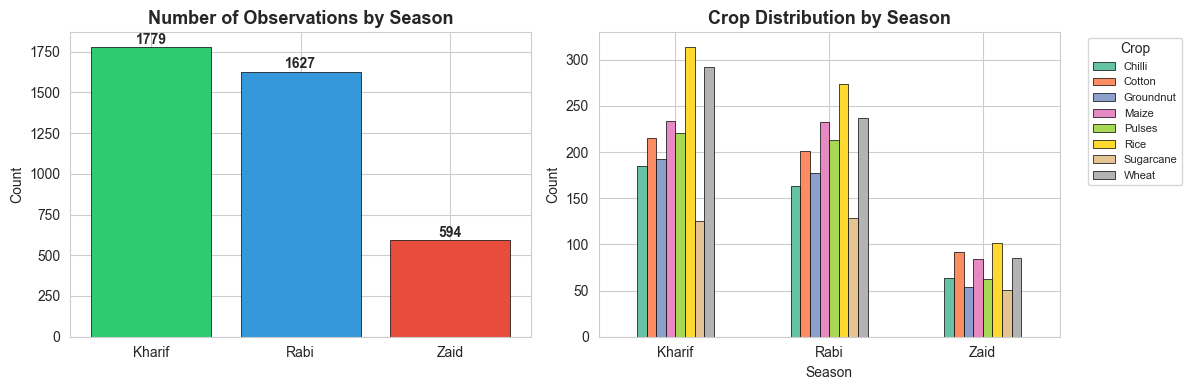

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Season counts
season_counts = data['Season'].value_counts().reindex(SEASON_ORDER)
axes[0].bar(season_counts.index, season_counts.values, color=[SEASON_PALETTE[s] for s in season_counts.index], edgecolor='black', linewidth=0.5)
axes[0].set_title('Number of Observations by Season', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(season_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Crop distribution by season
crop_season = data.groupby(['Season', 'Crop']).size().unstack(fill_value=0).reindex(SEASON_ORDER)
crop_season.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='black', linewidth=0.5)
axes[1].set_title('Crop Distribution by Season', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(SEASON_ORDER, rotation=0)
axes[1].legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

### 11.2 Distribution of Key Performance Variables

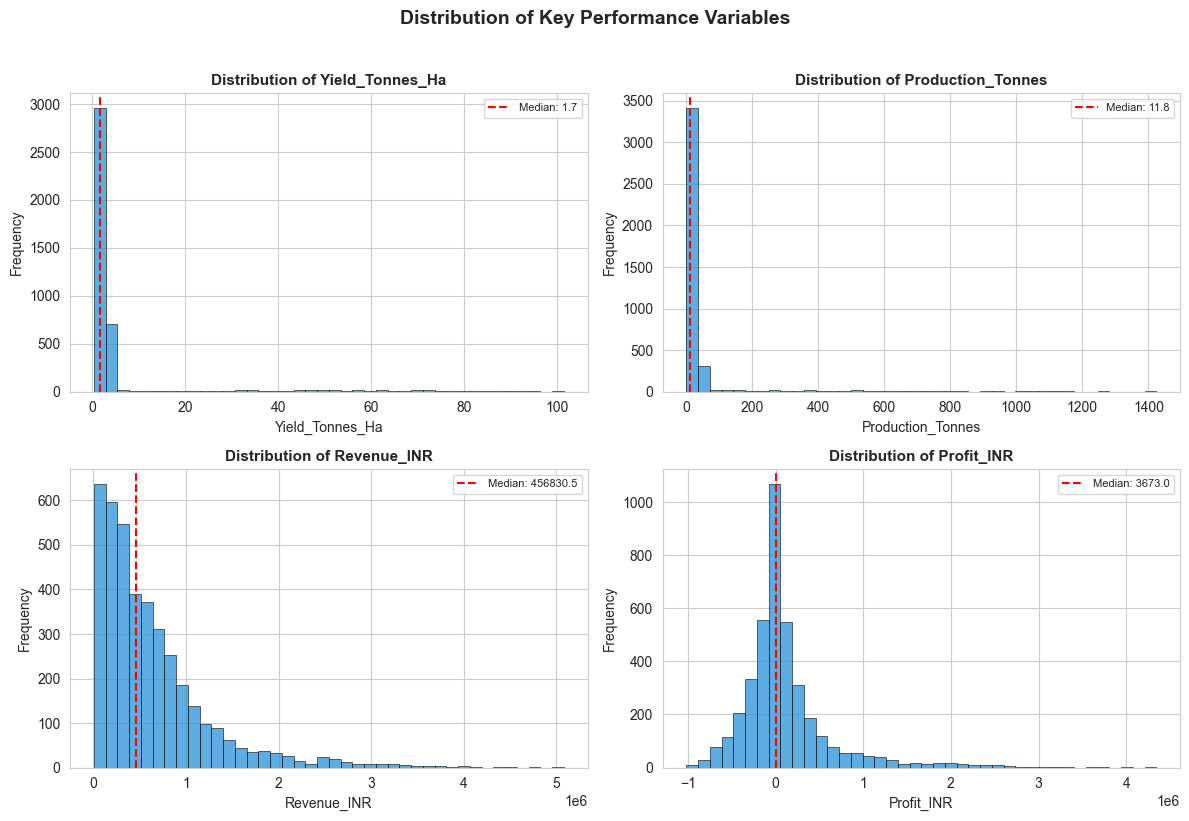

In [13]:
key_vars = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Profit_INR']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, var in zip(axes.flat, key_vars):
    data[var].dropna().hist(bins=40, ax=ax, color='#3498db', edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.set_title(f'Distribution of {var}', fontsize=11, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')
    ax.axvline(data[var].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {data[var].median():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Performance Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** The yield, production, revenue, and profit distributions are all right-skewed, with most observations concentrated at lower values and a long tail of higher values. This skewness means that the **median is a more representative measure of central tendency** than the mean for these variables.

## 12. Seasonal Agricultural Performance Analysis

This is the central analysis of the project. We compare yield, production, and related performance metrics across the three seasons.

### 12.1 Yield by Season

In [14]:
# Season-wise yield statistics
yield_by_season = data.groupby('Season')['Yield_Tonnes_Ha'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reindex(SEASON_ORDER).round(2)
yield_by_season.columns = ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
print('=== Yield (Tonnes/Ha) by Season ===')
yield_by_season

=== Yield (Tonnes/Ha) by Season ===


,Count,Mean,Median,Std Dev,Min,Max
Season,,,,,,
Kharif,1772,5.64,1.95,14.42,0.30,101.44
Rabi,1607,5.08,1.66,12.83,0.30,93.13
Zaid,589,4.67,1.45,11.32,0.30,64.76


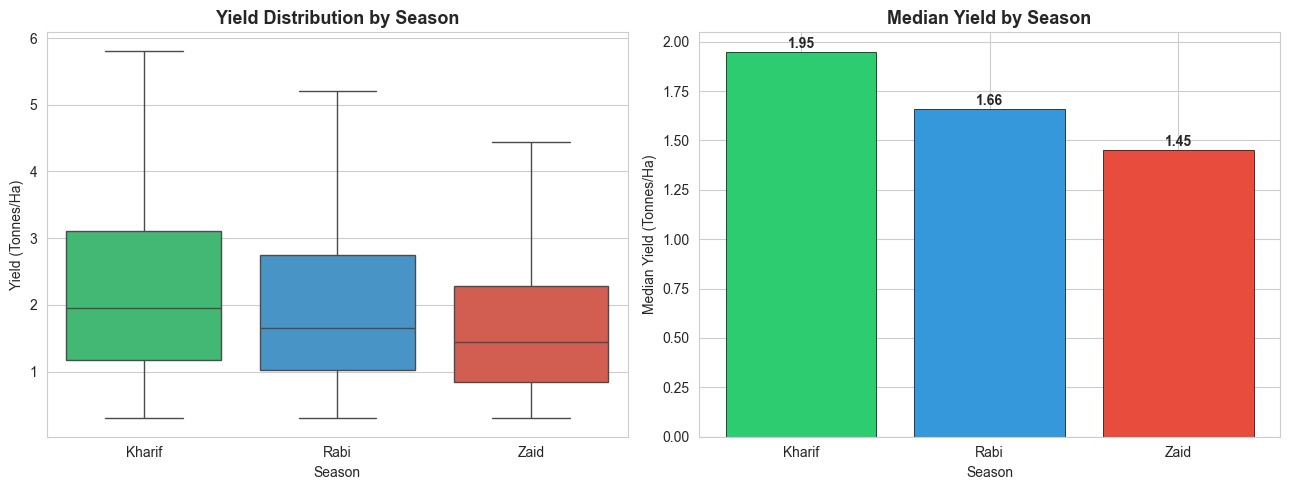

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
sns.boxplot(data=data, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[0], showfliers=False)
axes[0].set_title('Yield Distribution by Season', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Yield (Tonnes/Ha)')
axes[0].set_xlabel('Season')

# Bar chart of median yield
median_yield = data.groupby('Season')['Yield_Tonnes_Ha'].median().reindex(SEASON_ORDER)
bars = axes[1].bar(median_yield.index, median_yield.values, color=[SEASON_PALETTE[s] for s in median_yield.index], edgecolor='black', linewidth=0.5)
axes[1].set_title('Median Yield by Season', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Median Yield (Tonnes/Ha)')
axes[1].set_xlabel('Season')
for bar, val in zip(bars, median_yield.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:** The box plot reveals the spread and central tendency of yield across seasons. Any season with a higher median yield indicates more typical productivity, while wider boxes or more outliers suggest greater variability. The median is used alongside the mean because yield is right-skewed.

### 12.2 Production by Season

In [16]:
prod_by_season = data.groupby('Season')['Production_Tonnes'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reindex(SEASON_ORDER).round(2)
prod_by_season.columns = ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
print('=== Production (Tonnes) by Season ===')
prod_by_season

=== Production (Tonnes) by Season ===


,Count,Mean,Median,Std Dev,Min,Max
Season,,,,,,
Kharif,1779,46.31,13.24,135.70,0.20,1424.40
Rabi,1627,41.49,11.08,121.90,0.19,1249.21
Zaid,594,38.89,9.97,112.00,0.15,956.73


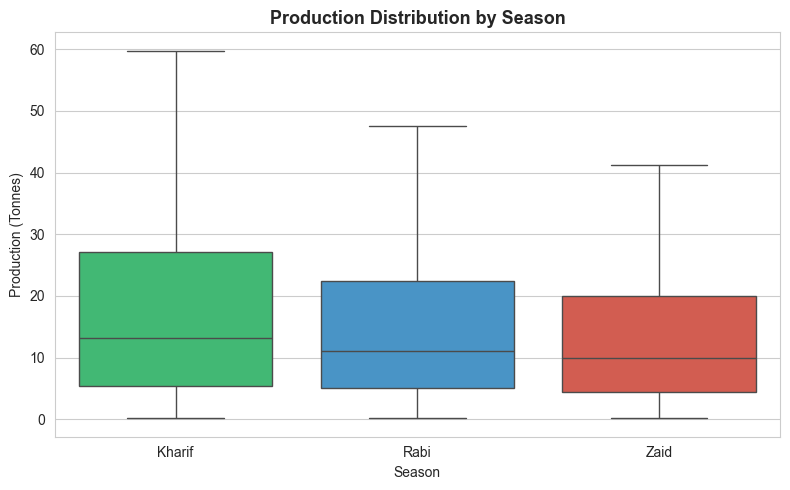

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=data, x='Season', y='Production_Tonnes', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=ax, showfliers=False)
ax.set_title('Production Distribution by Season', fontsize=13, fontweight='bold')
ax.set_ylabel('Production (Tonnes)')
ax.set_xlabel('Season')
plt.tight_layout()
plt.show()

### 12.3 Water Efficiency by Season

=== Water Efficiency (t/1000 m³) by Season ===
        Mean  Median  Std Dev
Season                       
Kharif  5.89    3.28     9.83
Rabi    5.19    2.74     8.26
Zaid    4.41    2.30     6.93


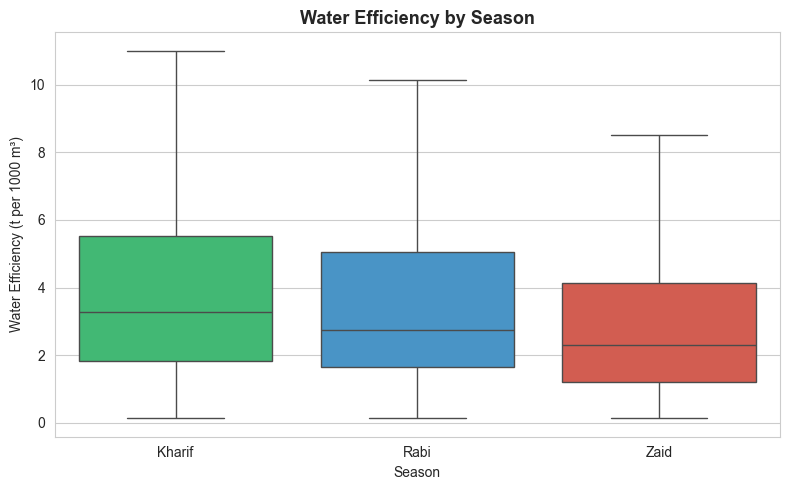

In [18]:
we_by_season = data.groupby('Season')['Water_Efficiency_t_per_1000m3'].agg(['mean', 'median', 'std']).reindex(SEASON_ORDER).round(2)
we_by_season.columns = ['Mean', 'Median', 'Std Dev']
print('=== Water Efficiency (t/1000 m³) by Season ===')
print(we_by_season)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=data, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=ax, showfliers=False)
ax.set_title('Water Efficiency by Season', fontsize=13, fontweight='bold')
ax.set_ylabel('Water Efficiency (t per 1000 m³)')
ax.set_xlabel('Season')
plt.tight_layout()
plt.show()

### 12.4 Disease/Pest Risk by Season

=== Disease/Pest Risk (%) by Season ===
        Mean  Median  Std Dev
Season                       
Kharif 54.47   54.50    10.09
Rabi   40.48   40.60    10.10
Zaid   38.22   37.90     9.87


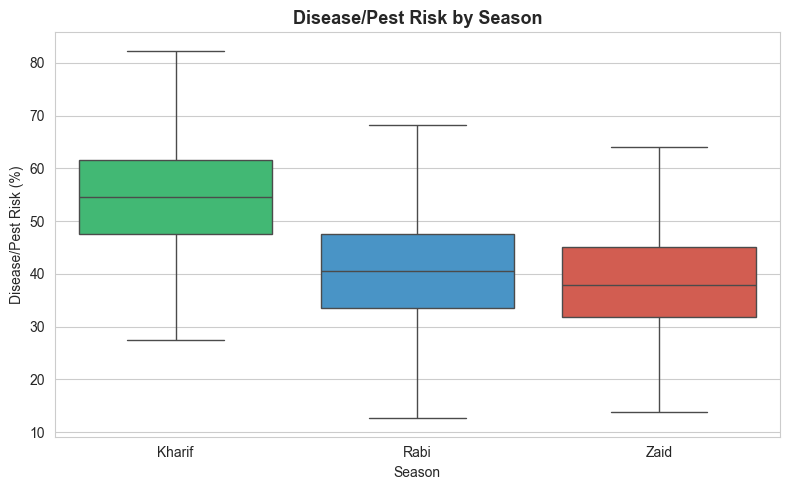

In [19]:
risk_by_season = data.groupby('Season')['Disease_Pest_Risk_pct'].agg(['mean', 'median', 'std']).reindex(SEASON_ORDER).round(2)
risk_by_season.columns = ['Mean', 'Median', 'Std Dev']
print('=== Disease/Pest Risk (%) by Season ===')
print(risk_by_season)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=data, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=ax, showfliers=False)
ax.set_title('Disease/Pest Risk by Season', fontsize=13, fontweight='bold')
ax.set_ylabel('Disease/Pest Risk (%)')
ax.set_xlabel('Season')
plt.tight_layout()
plt.show()

### 12.5 Summary of Seasonal Performance Metrics

In [20]:
perf_metrics = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
summary = data.groupby('Season')[perf_metrics].agg(['mean', 'median']).reindex(SEASON_ORDER).round(2)
print('=== Seasonal Performance Summary (Mean / Median) ===')
summary

=== Seasonal Performance Summary (Mean / Median) ===


Yield_Tonnes_Ha        Production_Tonnes         \
                  mean median              mean median   
Season                                                   
Kharif            5.64   1.95             46.31  13.24   
Rabi              5.08   1.66             41.49  11.08   
Zaid              4.67   1.45             38.89   9.97   

       Water_Efficiency_t_per_1000m3        Disease_Pest_Risk_pct         
                                mean median                  mean median  
Season                                                                    
Kharif                          5.89   3.28                 54.47  54.50  
Rabi                            5.19   2.74                 40.48  40.60  
Zaid                            4.41   2.30                 38.22  37.90

**Seasonal Performance Interpretation:**

The above summary compares the three seasons across key agricultural performance metrics. Differences in mean and median values indicate how typical performance varies by season, while standard deviation values from earlier tables show within-season variability. Seasons with higher yield but also higher variability may present both opportunities and risks for farmers.

## 13. Environmental Conditions by Season

We now examine how environmental conditions — the primary drivers of seasonal differences — vary across Kharif, Rabi, and Zaid.

In [21]:
env_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct']
env_stats = data.groupby('Season')[env_vars].agg(['mean', 'median', 'std']).reindex(SEASON_ORDER).round(2)
print('=== Environmental Conditions by Season ===')
env_stats

=== Environmental Conditions by Season ===


Rainfall_mm               Avg_Temperature_C             Humidity_pct  \
              mean median    std              mean median  std         mean   
Season                                                                        
Kharif      852.08 854.75 182.55             28.45  28.50 2.51        71.81   
Rabi        436.00 430.30 175.66             23.49  23.50 2.46        57.89   
Zaid        299.42 283.30 153.98             31.04  31.00 2.55        52.01   

                   Sunlight_Hours_Day             Soil_pH              \
       median  std               mean median  std    mean median  std   
Season                                                                  
Kharif  71.90 8.86               6.79   6.80 0.98    6.73   6.73 0.64   
Rabi    58.10 9.00               7.59   7.60 1.00    6.67   6.67 0.64   
Zaid    52.35 9.05               8.18   8.20 1.05    6.69   6.66 0.64   

       Soil_Moisture_pct              
                    mean median  std  
Season                                
Kharif             31.20  31.20 5.04  
Rabi               24.05  24.00 4.96  
Zaid               19.17  19.10 4.90

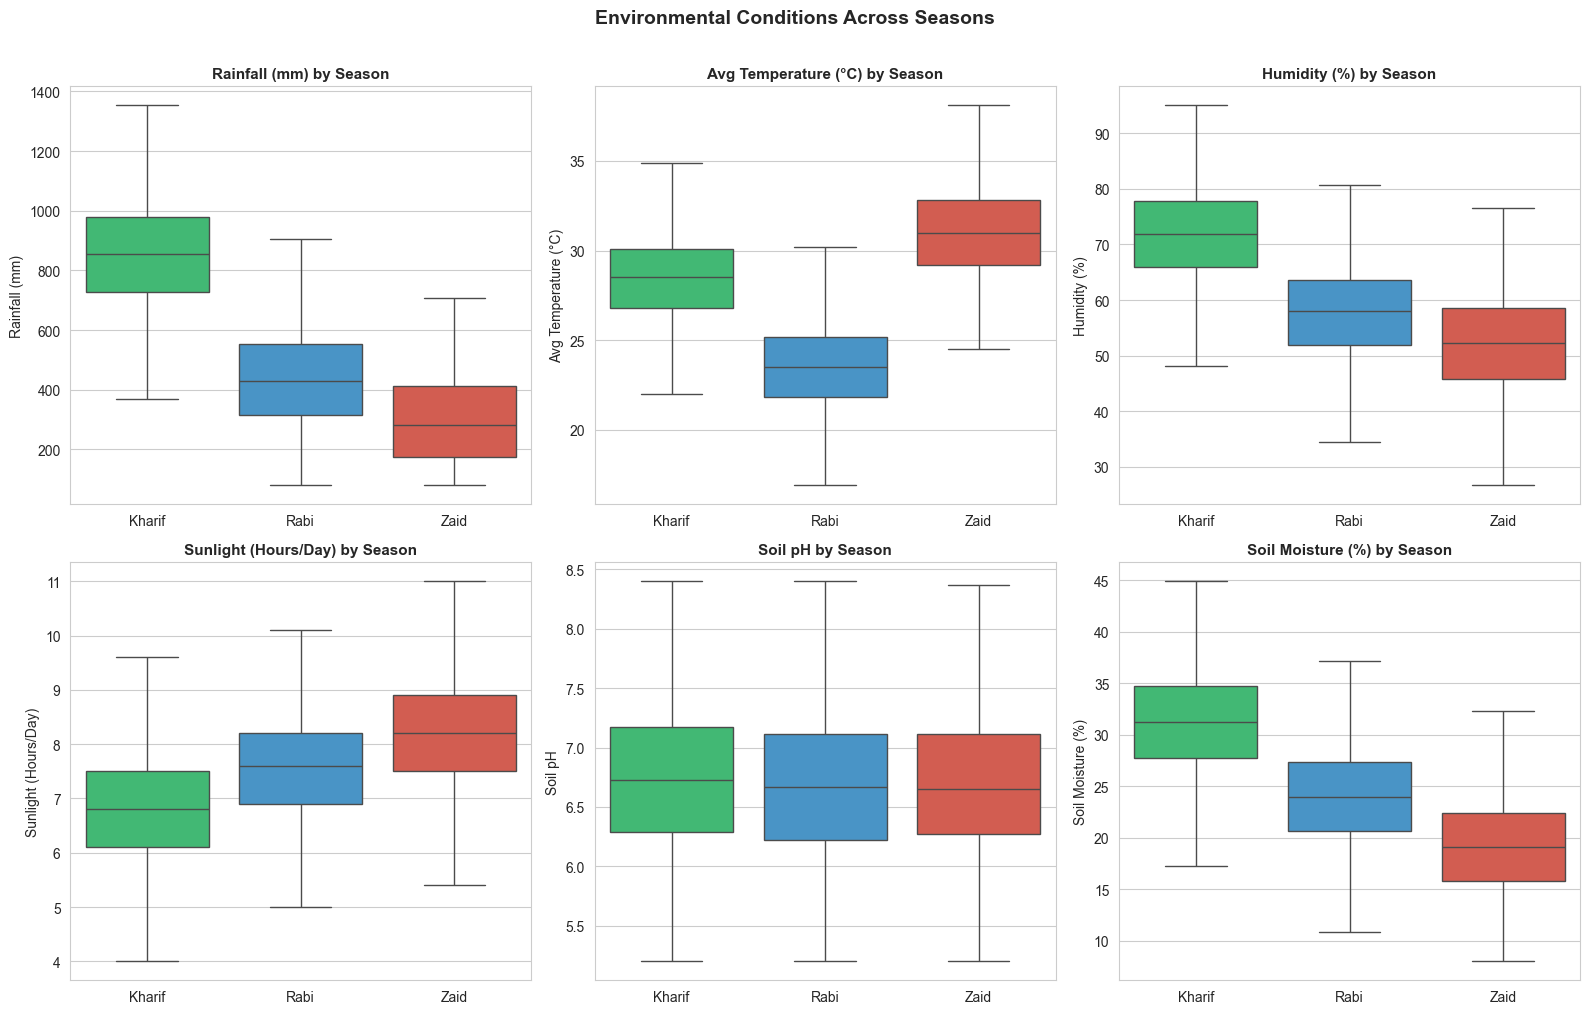

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

env_labels = [
    ('Rainfall_mm', 'Rainfall (mm)'),
    ('Avg_Temperature_C', 'Avg Temperature (°C)'),
    ('Humidity_pct', 'Humidity (%)'),
    ('Sunlight_Hours_Day', 'Sunlight (Hours/Day)'),
    ('Soil_pH', 'Soil pH'),
    ('Soil_Moisture_pct', 'Soil Moisture (%)')
]

for ax, (col, label) in zip(axes.flat, env_labels):
    sns.boxplot(data=data, x='Season', y=col, order=SEASON_ORDER,
                palette=SEASON_PALETTE, ax=ax, showfliers=False)
    ax.set_title(f'{label} by Season', fontsize=11, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_xlabel('')

plt.suptitle('Environmental Conditions Across Seasons', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Environmental Interpretation:**

The box plots above visualize how each environmental factor varies across seasons. Key observations include:
- **Rainfall**: Expected to be highest during Kharif (monsoon season) and lowest during Zaid/Rabi.
- **Temperature**: May be higher during Zaid (summer) compared to Rabi (winter).
- **Humidity**: Likely correlates with rainfall patterns.
- **Soil conditions**: May show less pronounced seasonal variation depending on geography.

These environmental differences set the stage for understanding why agricultural performance varies by season.

### 13.1 Environmental Factors vs. Yield (Scatter Plots)

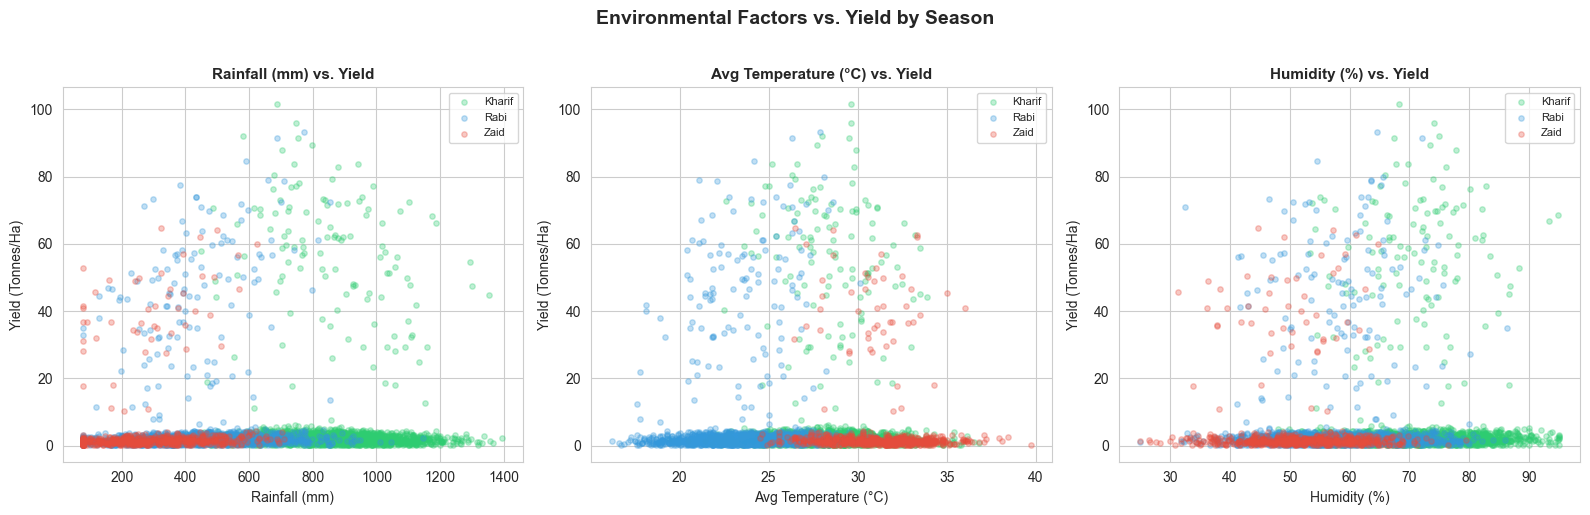

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']
scatter_labels = ['Rainfall (mm)', 'Avg Temperature (°C)', 'Humidity (%)']

for ax, var, label in zip(axes, scatter_vars, scatter_labels):
    for season in SEASON_ORDER:
        subset = data[data['Season'] == season]
        ax.scatter(subset[var], subset['Yield_Tonnes_Ha'], alpha=0.3, s=15,
                   color=SEASON_PALETTE[season], label=season)
    ax.set_xlabel(label)
    ax.set_ylabel('Yield (Tonnes/Ha)')
    ax.set_title(f'{label} vs. Yield', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Environmental Factors vs. Yield by Season', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Resource Usage by Season

In [24]:
resource_vars = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']
resource_stats = data.groupby('Season')[resource_vars].agg(['mean', 'median']).reindex(SEASON_ORDER).round(2)
print('=== Resource Usage by Season (Mean / Median) ===')
resource_stats

=== Resource Usage by Season (Mean / Median) ===


Fertilizer_kg_ha        Pesticide_Litre_ha        Water_Used_m3  \
                   mean median               mean median          mean   
Season                                                                   
Kharif           187.08 188.20               5.08   5.18       6102.20   
Rabi             185.41 185.30               5.02   5.02       5846.99   
Zaid             184.64 183.95               5.17   5.18       6419.89   

               Nitrogen_kg_ha        Phosphorus_kg_ha        Potassium_kg_ha  \
        median           mean median             mean median            mean   
Season                                                                         
Kharif 4469.00         120.02 119.80            58.10  57.40          105.30   
Rabi   4292.00         120.40 120.30            57.31  57.70          103.93   
Zaid   4805.00         120.53 120.15            58.13  57.45          105.42   

               
       median  
Season         
Kharif 104.80  
Rabi   104.80  
Zaid   106.30

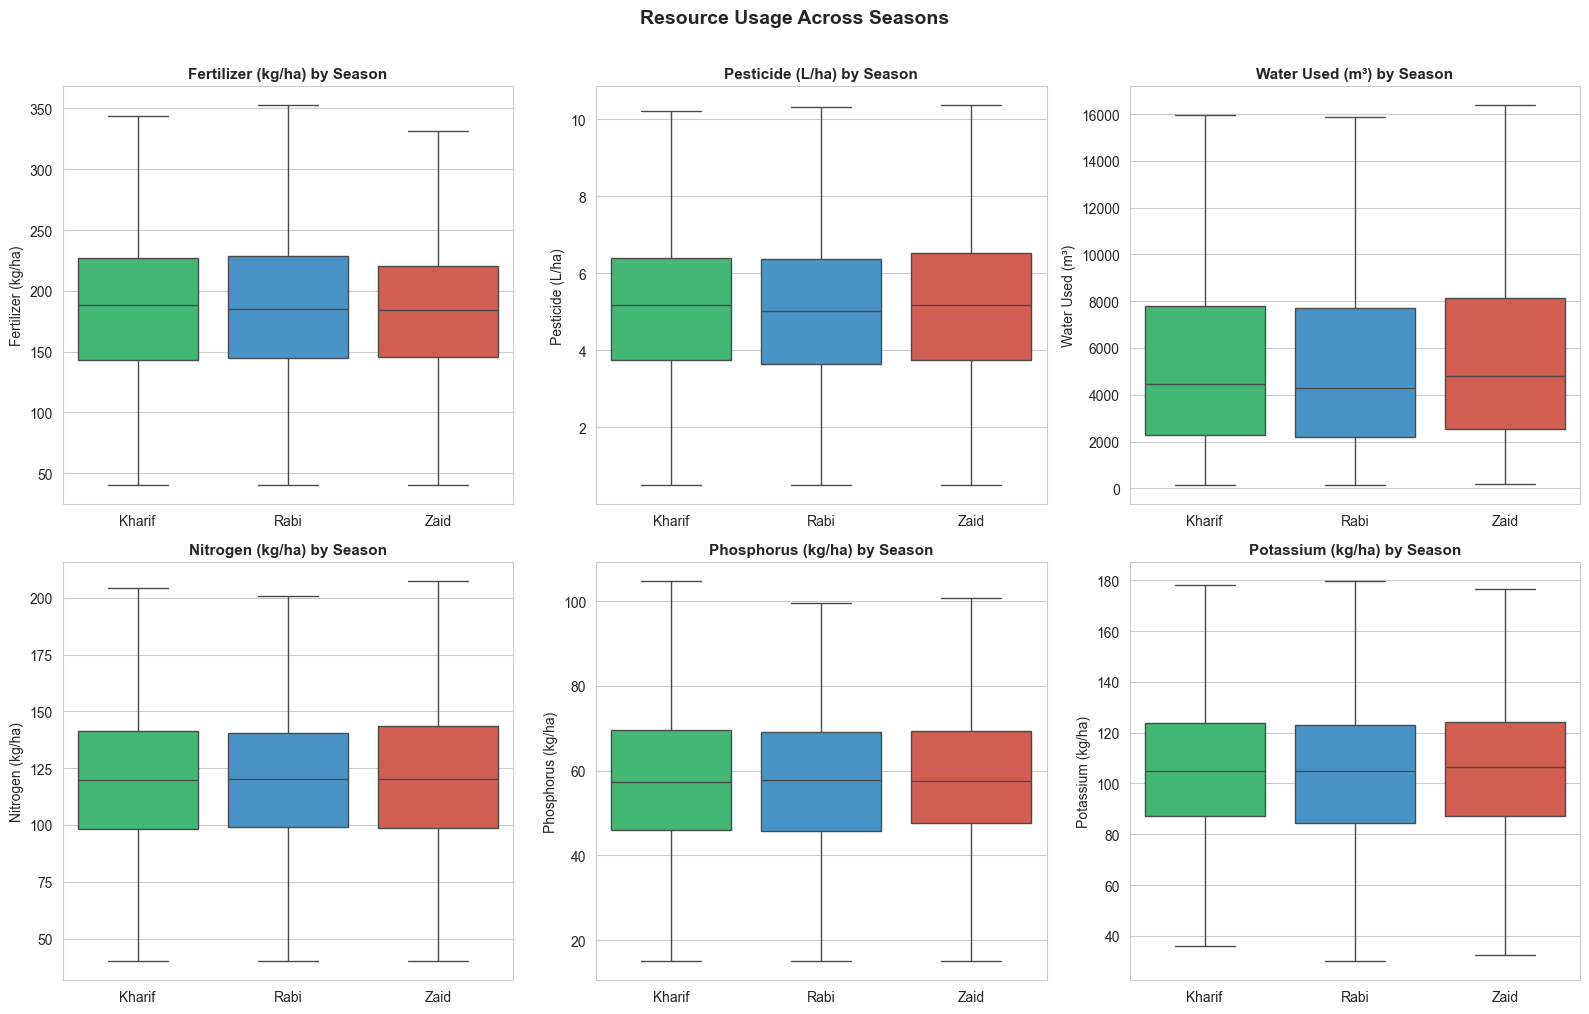

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

res_labels = [
    ('Fertilizer_kg_ha', 'Fertilizer (kg/ha)'),
    ('Pesticide_Litre_ha', 'Pesticide (L/ha)'),
    ('Water_Used_m3', 'Water Used (m³)'),
    ('Nitrogen_kg_ha', 'Nitrogen (kg/ha)'),
    ('Phosphorus_kg_ha', 'Phosphorus (kg/ha)'),
    ('Potassium_kg_ha', 'Potassium (kg/ha)')
]

for ax, (col, label) in zip(axes.flat, res_labels):
    sns.boxplot(data=data, x='Season', y=col, order=SEASON_ORDER,
                palette=SEASON_PALETTE, ax=ax, showfliers=False)
    ax.set_title(f'{label} by Season', fontsize=11, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_xlabel('')

plt.suptitle('Resource Usage Across Seasons', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 14.1 Irrigation Method Distribution by Season

=== Irrigation Method by Season ===
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    590      463        321
Rabi                370    526      438        293
Zaid                140    194      140        120


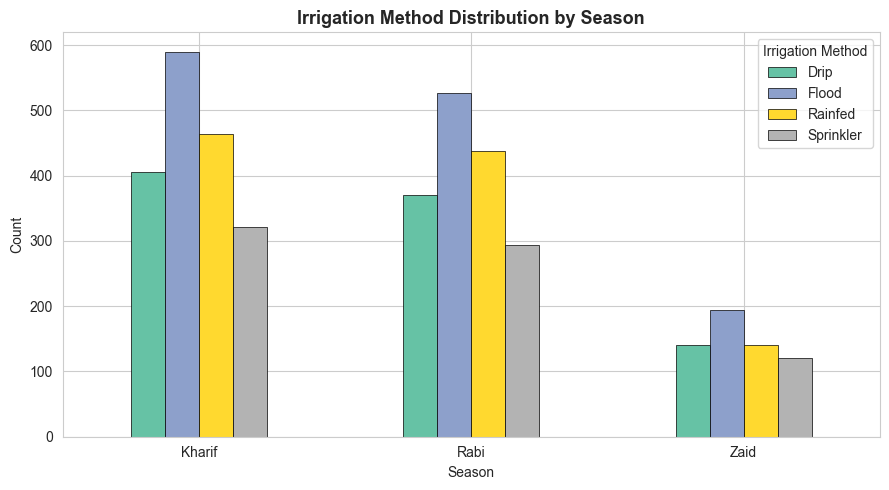

In [26]:
irr_season = pd.crosstab(data['Season'], data['Irrigation_Method']).reindex(SEASON_ORDER)
print('=== Irrigation Method by Season ===')
print(irr_season)

fig, ax = plt.subplots(figsize=(9, 5))
irr_season.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5)
ax.set_title('Irrigation Method Distribution by Season', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xticklabels(SEASON_ORDER, rotation=0)
ax.legend(title='Irrigation Method')
plt.tight_layout()
plt.show()

### 14.2 Resource Usage vs. Yield

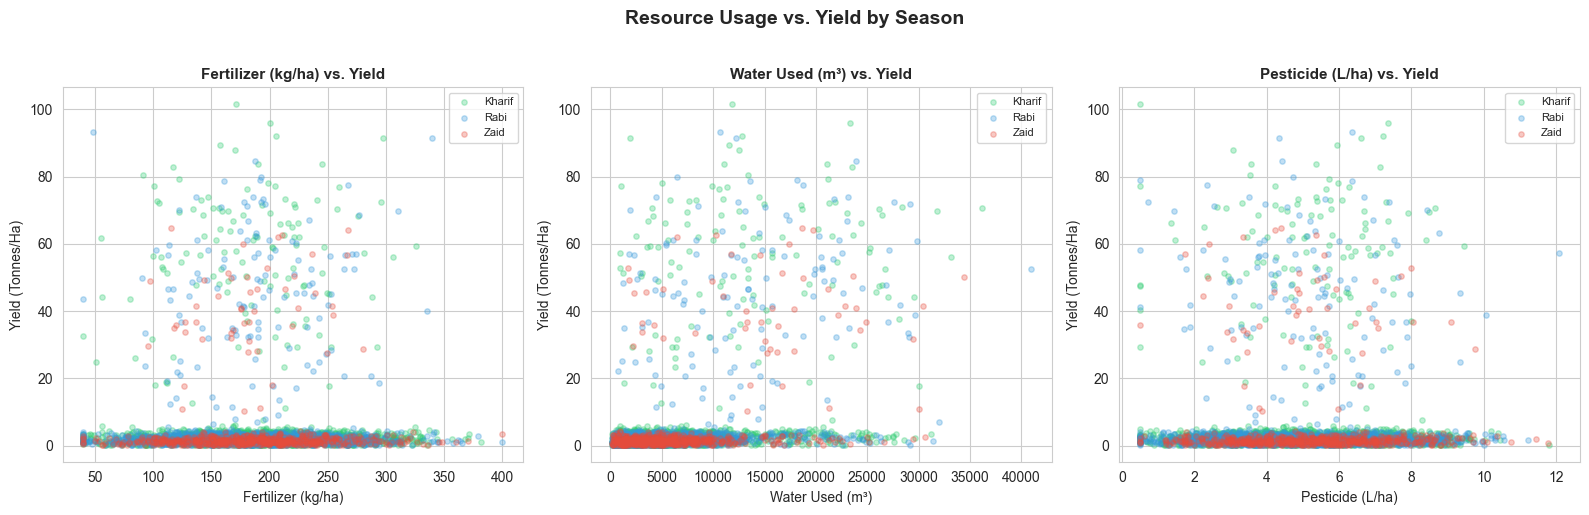

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

res_scatter = [('Fertilizer_kg_ha', 'Fertilizer (kg/ha)'), ('Water_Used_m3', 'Water Used (m³)'), ('Pesticide_Litre_ha', 'Pesticide (L/ha)')]

for ax, (var, label) in zip(axes, res_scatter):
    for season in SEASON_ORDER:
        subset = data[data['Season'] == season]
        ax.scatter(subset[var], subset['Yield_Tonnes_Ha'], alpha=0.3, s=15,
                   color=SEASON_PALETTE[season], label=season)
    ax.set_xlabel(label)
    ax.set_ylabel('Yield (Tonnes/Ha)')
    ax.set_title(f'{label} vs. Yield', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Resource Usage vs. Yield by Season', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Resource Usage Interpretation:**

The comparison of resource usage across seasons reveals whether certain seasons require more inputs (water, fertilizer, pesticide). The scatter plots help assess whether higher resource inputs are associated with higher yields, or whether the relationship is weak — suggesting that resource efficiency, not just resource volume, matters for agricultural performance.

## 15. Crop-wise Seasonal Analysis

In [28]:
# Median yield by crop and season
crop_season_yield = data.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].median().unstack().reindex(columns=SEASON_ORDER).round(2)
print('=== Median Yield (Tonnes/Ha) by Crop and Season ===')
crop_season_yield

=== Median Yield (Tonnes/Ha) by Crop and Season ===


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.78,1.56,1.22
Cotton,1.44,1.20,0.97
Groundnut,1.52,1.29,1.10
Maize,3.12,2.82,2.27
Pulses,1.09,0.90,0.66
Rice,2.88,2.38,1.94
Sugarcane,56.65,45.46,38.78
Wheat,2.36,2.22,1.84


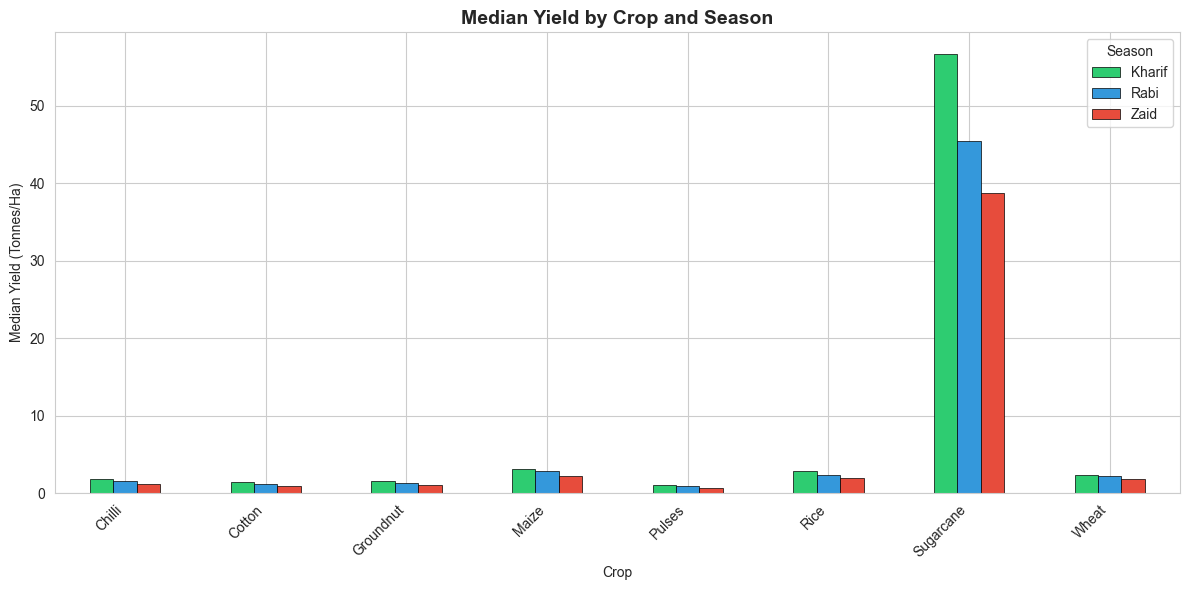

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
crop_season_yield.plot(kind='bar', ax=ax, color=[SEASON_PALETTE[s] for s in SEASON_ORDER], edgecolor='black', linewidth=0.5)
ax.set_title('Median Yield by Crop and Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Median Yield (Tonnes/Ha)')
ax.set_xlabel('Crop')
ax.set_xticklabels(crop_season_yield.index, rotation=45, ha='right')
ax.legend(title='Season')
plt.tight_layout()
plt.show()

In [30]:
# Median profit by crop and season
crop_season_profit = data.groupby(['Crop', 'Season'])['Profit_INR'].median().unstack().reindex(columns=SEASON_ORDER).round(0)
print('=== Median Profit (INR) by Crop and Season ===')
crop_season_profit

=== Median Profit (INR) by Crop and Season ===


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,705116.00,470004.00,350401.00
Cotton,136193.00,50603.00,-11434.00
Groundnut,87406.00,24517.00,-38896.00
Maize,-9884.00,-45813.00,-147456.00
Pulses,57156.00,-11734.00,-128893.00
Rice,-39904.00,-49932.00,-183632.00
Sugarcane,940895.00,622229.00,556627.00
Wheat,-57248.00,-76084.00,-125778.00


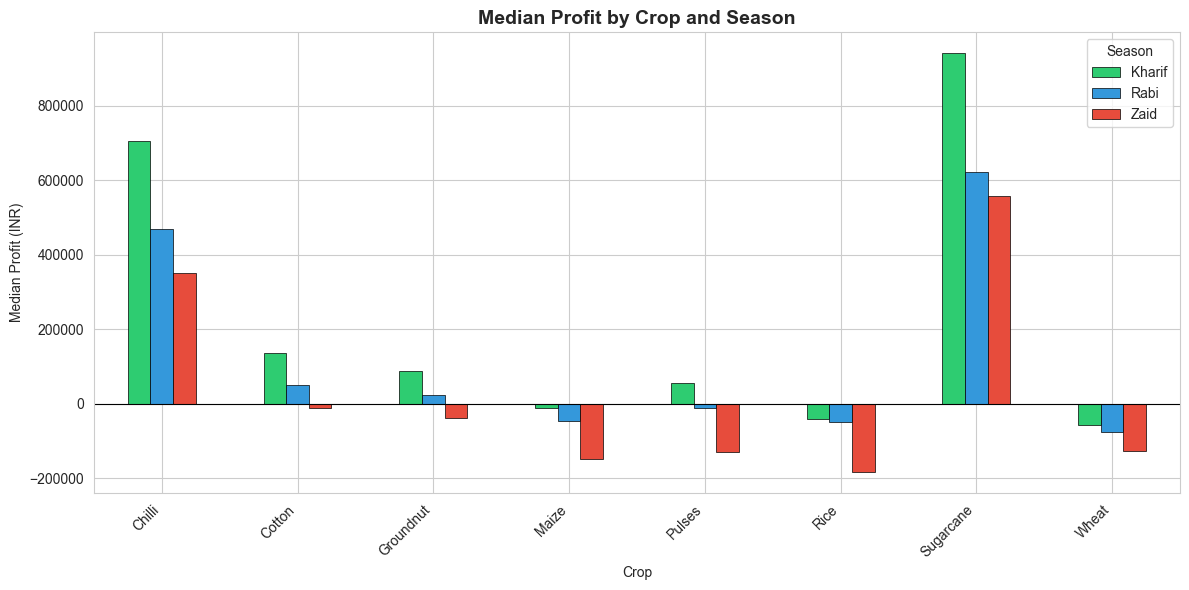

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
crop_season_profit.plot(kind='bar', ax=ax, color=[SEASON_PALETTE[s] for s in SEASON_ORDER], edgecolor='black', linewidth=0.5)
ax.set_title('Median Profit by Crop and Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Median Profit (INR)')
ax.set_xlabel('Crop')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticklabels(crop_season_profit.index, rotation=45, ha='right')
ax.legend(title='Season')
plt.tight_layout()
plt.show()

**Crop-wise Interpretation:**

The crop-season comparison reveals whether the overall seasonal pattern holds for individual crops or whether certain crops perform differently. Crops with strong seasonal preferences show large differences across seasons, while crops with minimal seasonal variation may be more adaptable.

## 16. Regional Seasonal Analysis

In [32]:
# Median yield by state and season
state_season_yield = data.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].median().unstack().reindex(columns=SEASON_ORDER).round(2)
print('=== Median Yield (Tonnes/Ha) by State and Season ===')
state_season_yield

=== Median Yield (Tonnes/Ha) by State and Season ===


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,2.05,1.33,1.58
Gujarat,1.80,1.58,1.60
Karnataka,2.00,1.67,1.33
Madhya Pradesh,1.98,1.58,1.36
Maharashtra,2.01,1.65,1.42
Punjab,1.86,1.87,1.33
Tamil Nadu,1.72,1.85,1.45
Telangana,2.12,1.72,1.40


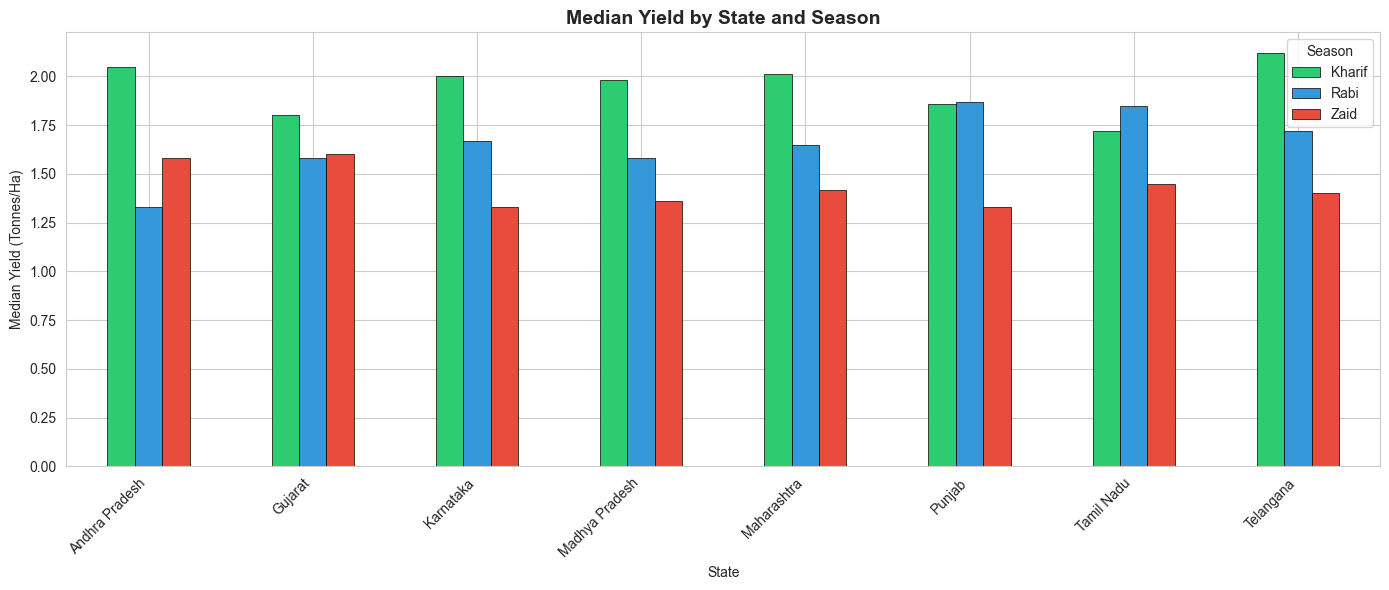

In [33]:
fig, ax = plt.subplots(figsize=(14, 6))
state_season_yield.plot(kind='bar', ax=ax, color=[SEASON_PALETTE[s] for s in SEASON_ORDER], edgecolor='black', linewidth=0.5)
ax.set_title('Median Yield by State and Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Median Yield (Tonnes/Ha)')
ax.set_xlabel('State')
ax.set_xticklabels(state_season_yield.index, rotation=45, ha='right')
ax.legend(title='Season')
plt.tight_layout()
plt.show()

In [34]:
# Median profit by state and season
state_season_profit = data.groupby(['State', 'Season'])['Profit_INR'].median().unstack().reindex(columns=SEASON_ORDER).round(0)
print('=== Median Profit (INR) by State and Season ===')
state_season_profit

=== Median Profit (INR) by State and Season ===


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,36666.00,-6366.00,-55525.00
Gujarat,42337.00,-7532.00,-119121.00
Karnataka,47792.00,-301.00,-53754.00
Madhya Pradesh,29770.00,-17858.00,-92531.00
Maharashtra,22112.00,2398.00,-63377.00
Punjab,35671.00,9452.00,-22060.00
Tamil Nadu,32754.00,-11212.00,-51176.00
Telangana,58910.00,11408.00,-62725.00


**Regional Interpretation:**

Regional differences help identify whether certain states consistently outperform others across seasons or whether the best-performing season varies by geography. This information is valuable for region-specific agricultural planning.

## 17. Economic Performance by Season

In [35]:
econ_vars = ['Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
econ_stats = data.groupby('Season')[econ_vars].agg(['mean', 'median', 'std']).reindex(SEASON_ORDER).round(0)
print('=== Economic Performance by Season ===')
econ_stats

=== Economic Performance by Season ===


Market_Price_INR_Tonne                   Total_Cost_INR            \
                         mean   median      std           mean    median   
Season                                                                     
Kharif               44851.00 25793.00 30302.00      531804.00 524840.00   
Rabi                 44748.00 26041.00 30310.00      513837.00 506733.00   
Zaid                 44212.00 25750.00 30086.00      543977.00 534833.00   

                 Revenue_INR                     Profit_INR            \
             std        mean    median       std       mean    median   
Season                                                                  
Kharif 298488.00   710719.00 520196.00 708710.00  178915.00  38808.00   
Rabi   288387.00   601526.00 438156.00 584546.00   87689.00  -3187.00   
Zaid   297577.00   519172.00 373700.00 509525.00  -24805.00 -62144.00   

                  
             std  
Season            
Kharif 611550.00  
Rabi   489901.00  
Zaid   436357.00

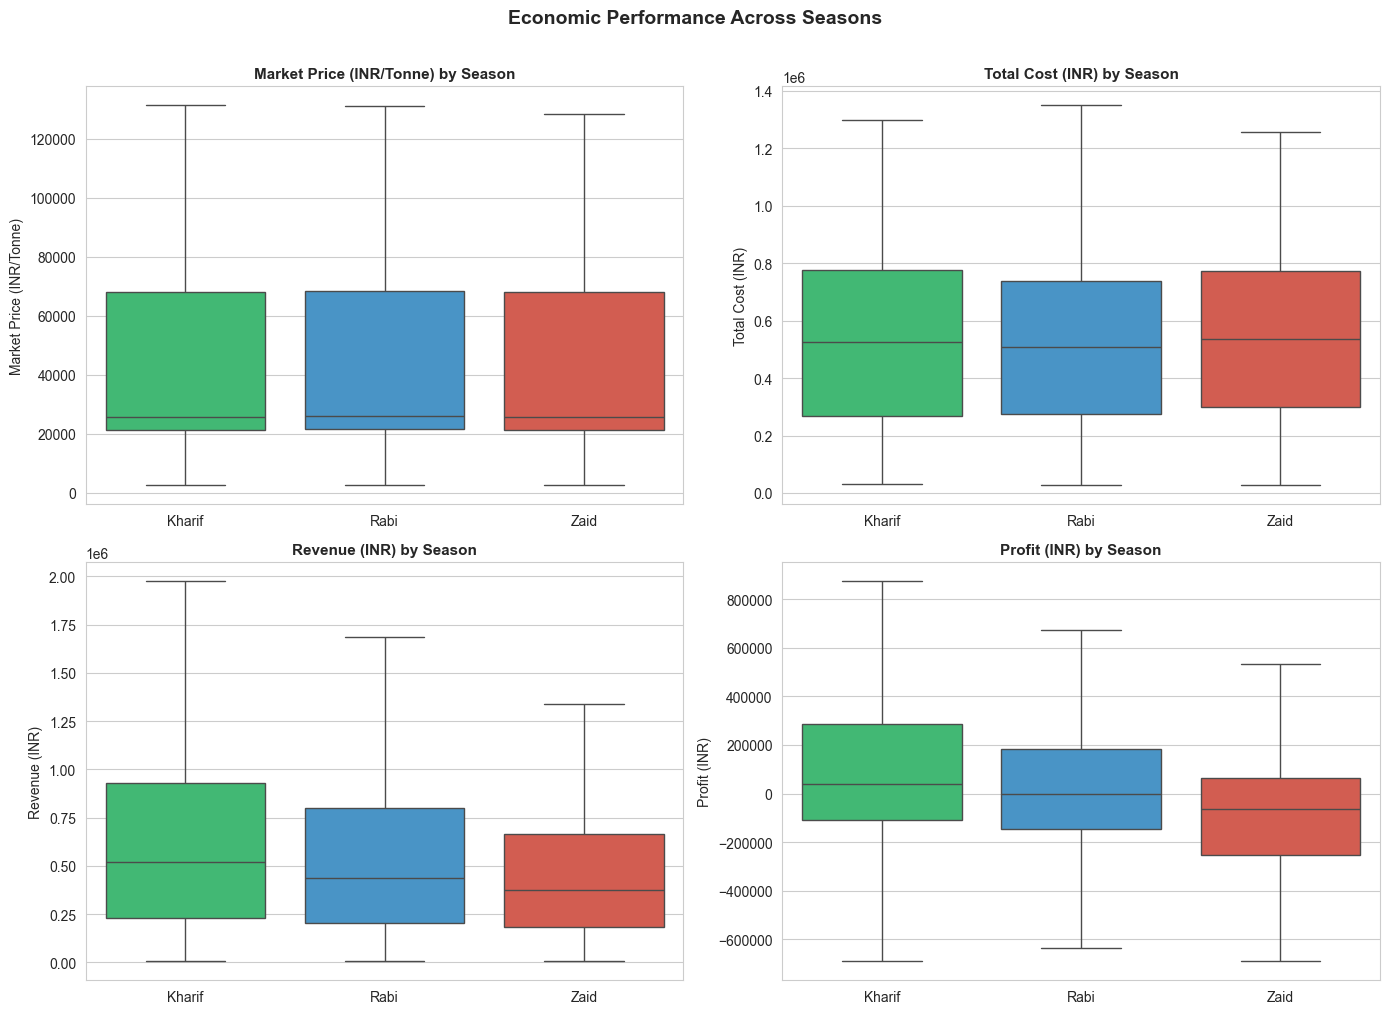

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

econ_labels = [
    ('Market_Price_INR_Tonne', 'Market Price (INR/Tonne)'),
    ('Total_Cost_INR', 'Total Cost (INR)'),
    ('Revenue_INR', 'Revenue (INR)'),
    ('Profit_INR', 'Profit (INR)')
]

for ax, (col, label) in zip(axes.flat, econ_labels):
    sns.boxplot(data=data, x='Season', y=col, order=SEASON_ORDER,
                palette=SEASON_PALETTE, ax=ax, showfliers=False)
    ax.set_title(f'{label} by Season', fontsize=11, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_xlabel('')

plt.suptitle('Economic Performance Across Seasons', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== Percentage of Profitable Farms by Season ===
Kharif: 57.8%
Rabi: 48.9%
Zaid: 35.5%


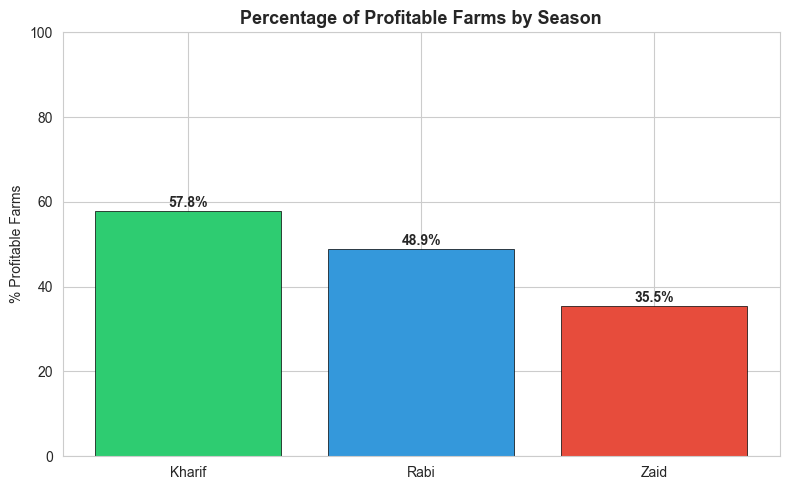

In [37]:
# Profitability rate by season
profit_rate = data.groupby('Season').apply(lambda x: (x['Profit_INR'] > 0).mean() * 100).reindex(SEASON_ORDER).round(1)
print('=== Percentage of Profitable Farms by Season ===')
for season, rate in profit_rate.items():
    print(f'{season}: {rate}%')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(profit_rate.index, profit_rate.values, color=[SEASON_PALETTE[s] for s in profit_rate.index], edgecolor='black', linewidth=0.5)
ax.set_title('Percentage of Profitable Farms by Season', fontsize=13, fontweight='bold')
ax.set_ylabel('% Profitable Farms')
ax.set_ylim(0, 100)
for bar, val in zip(bars, profit_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Economic Interpretation:**

Economic performance reveals whether seasons with higher agricultural output also deliver higher profits. The profitability rate shows what proportion of farms earn positive returns in each season. A season with high production but low profitability could indicate higher costs or lower market prices, making the distinction between production performance and economic performance important.

## 18. Correlation Analysis

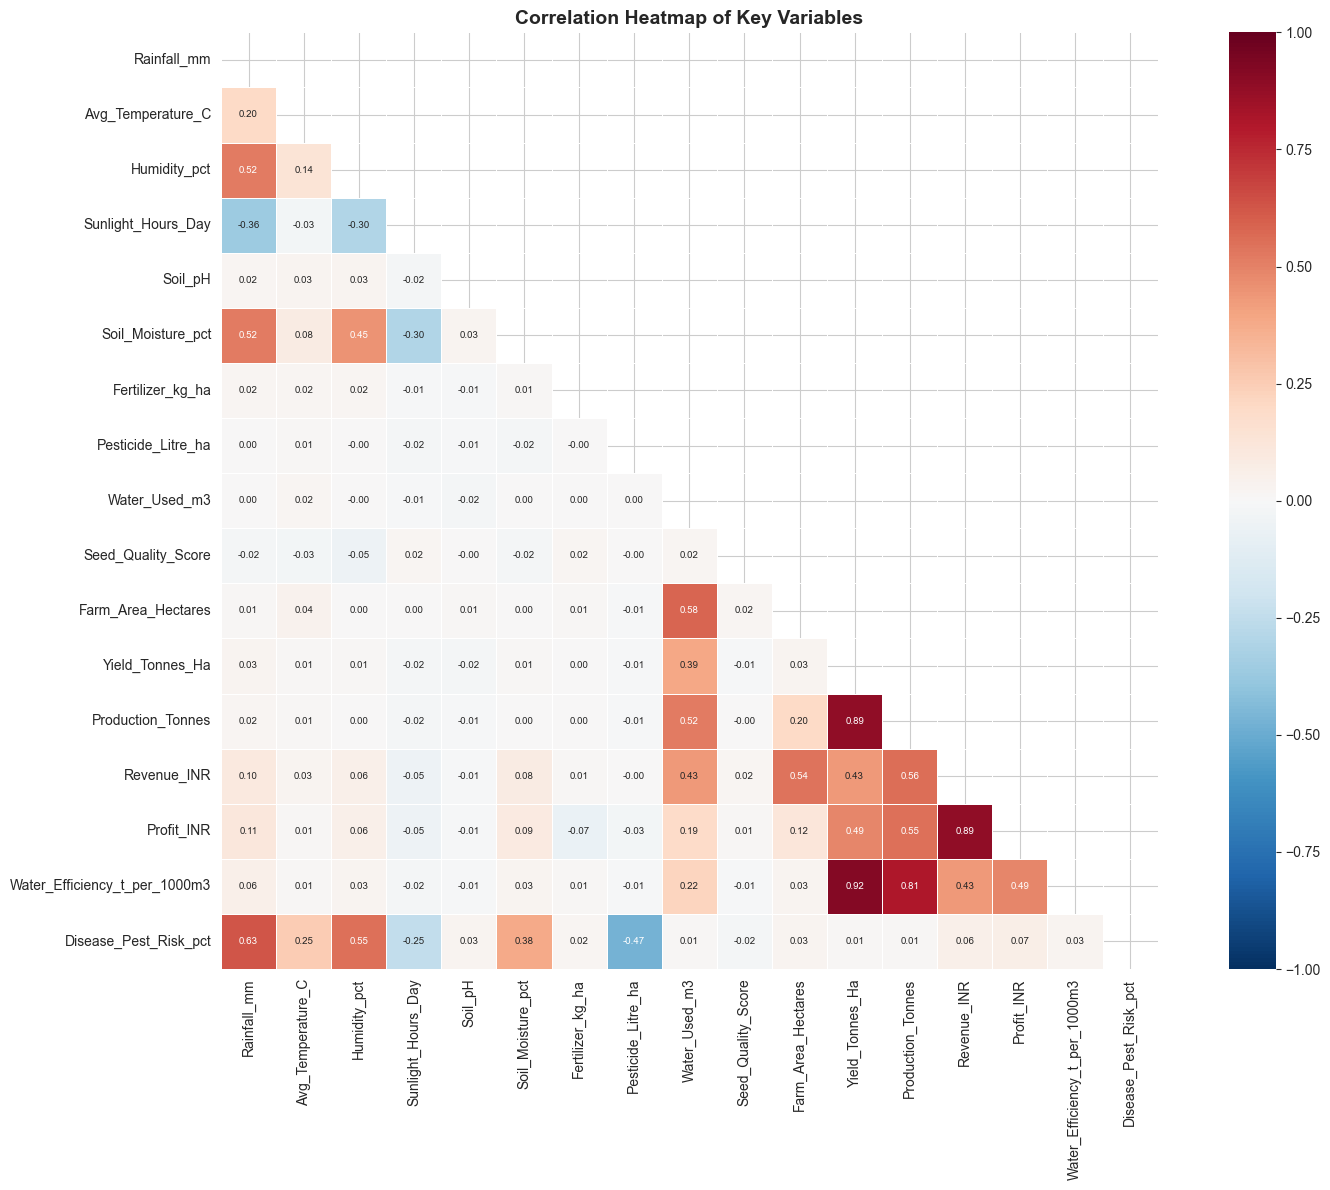

In [38]:
# Select relevant numerical variables for correlation
corr_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
             'Soil_pH', 'Soil_Moisture_pct', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
             'Water_Used_m3', 'Seed_Quality_Score', 'Farm_Area_Hectares',
             'Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Profit_INR',
             'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

corr_matrix = data[corr_vars].corr().round(2)

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7},
            vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# Strongest correlations with Yield
yield_corr = corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False)
print('=== Correlations with Yield (sorted by strength) ===')
for var, r in yield_corr.items():
    strength = 'strong' if abs(r) > 0.5 else 'moderate' if abs(r) > 0.3 else 'weak'
    direction = 'positive' if r > 0 else 'negative'
    print(f'{var:>40s}: r = {r:+.2f} ({strength} {direction})')

=== Correlations with Yield (sorted by strength) ===
           Water_Efficiency_t_per_1000m3: r = +0.92 (strong positive)
                       Production_Tonnes: r = +0.89 (strong positive)
                              Profit_INR: r = +0.49 (moderate positive)
                             Revenue_INR: r = +0.43 (moderate positive)
                           Water_Used_m3: r = +0.39 (moderate positive)
                             Rainfall_mm: r = +0.03 (weak positive)
                      Farm_Area_Hectares: r = +0.03 (weak positive)
                      Sunlight_Hours_Day: r = -0.02 (weak negative)
                                 Soil_pH: r = -0.02 (weak negative)
                       Avg_Temperature_C: r = +0.01 (weak positive)
                       Soil_Moisture_pct: r = +0.01 (weak positive)
                            Humidity_pct: r = +0.01 (weak positive)
                      Seed_Quality_Score: r = -0.01 (weak negative)
                      Pesticide_Litre_ha: r = -

In [40]:
# Strongest correlations with Profit
profit_corr = corr_matrix['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False)
print('=== Correlations with Profit (sorted by strength) ===')
for var, r in profit_corr.items():
    strength = 'strong' if abs(r) > 0.5 else 'moderate' if abs(r) > 0.3 else 'weak'
    direction = 'positive' if r > 0 else 'negative'
    print(f'{var:>40s}: r = {r:+.2f} ({strength} {direction})')

=== Correlations with Profit (sorted by strength) ===
                             Revenue_INR: r = +0.89 (strong positive)
                       Production_Tonnes: r = +0.55 (strong positive)
           Water_Efficiency_t_per_1000m3: r = +0.49 (moderate positive)
                         Yield_Tonnes_Ha: r = +0.49 (moderate positive)
                           Water_Used_m3: r = +0.19 (weak positive)
                      Farm_Area_Hectares: r = +0.12 (weak positive)
                             Rainfall_mm: r = +0.11 (weak positive)
                       Soil_Moisture_pct: r = +0.09 (weak positive)
                   Disease_Pest_Risk_pct: r = +0.07 (weak positive)
                        Fertilizer_kg_ha: r = -0.07 (weak negative)
                            Humidity_pct: r = +0.06 (weak positive)
                      Sunlight_Hours_Day: r = -0.05 (weak negative)
                      Pesticide_Litre_ha: r = -0.03 (weak negative)
                       Avg_Temperature_C: r = +0.0

**Correlation Interpretation:**

The correlation analysis identifies which variables show the strongest linear associations with yield and profit. It is important to note that **correlation does not imply causation** — these relationships indicate associations observed in the data, not causal mechanisms. The heatmap also reveals relationships among input variables themselves, which can help understand the interconnected nature of agricultural factors.

## 19. Statistical Analysis

To determine whether the observed seasonal differences in yield and profit are statistically significant, we apply appropriate statistical tests.

### 19.1 Kruskal-Wallis Test for Yield Across Seasons

Since yield is highly right-skewed, the **Kruskal-Wallis test** (a non-parametric alternative to one-way ANOVA) is more appropriate than ANOVA. It tests whether the distributions of yield differ significantly across the three seasons.

**Hypotheses:**
- H₀: The distribution of yield is the same across all three seasons.
- H₁: At least one season's yield distribution differs from the others.

In [41]:
# Kruskal-Wallis test for Yield across seasons
yield_groups = [data[data['Season'] == s]['Yield_Tonnes_Ha'].dropna() for s in SEASON_ORDER]
kw_stat, kw_p = stats.kruskal(*yield_groups)

print('=== Kruskal-Wallis Test: Yield Across Seasons ===')
print(f'Test Statistic (H): {kw_stat:.4f}')
print(f'p-value: {kw_p:.6f}')
if kw_p < 0.05:
    print('Result: The differences in yield distributions across seasons are statistically significant (p < 0.05).')
else:
    print('Result: No statistically significant difference in yield distributions across seasons (p >= 0.05).')

=== Kruskal-Wallis Test: Yield Across Seasons ===
Test Statistic (H): 68.6043
p-value: 0.000000
Result: The differences in yield distributions across seasons are statistically significant (p < 0.05).


### 19.2 Kruskal-Wallis Test for Profit Across Seasons

In [42]:
profit_groups = [data[data['Season'] == s]['Profit_INR'].dropna() for s in SEASON_ORDER]
kw_stat_p, kw_p_p = stats.kruskal(*profit_groups)

print('=== Kruskal-Wallis Test: Profit Across Seasons ===')
print(f'Test Statistic (H): {kw_stat_p:.4f}')
print(f'p-value: {kw_p_p:.6f}')
if kw_p_p < 0.05:
    print('Result: The differences in profit distributions across seasons are statistically significant (p < 0.05).')
else:
    print('Result: No statistically significant difference in profit distributions across seasons (p >= 0.05).')

=== Kruskal-Wallis Test: Profit Across Seasons ===
Test Statistic (H): 101.9261
p-value: 0.000000
Result: The differences in profit distributions across seasons are statistically significant (p < 0.05).


### 19.3 Kruskal-Wallis Test for Key Environmental Variables

In [43]:
print('=== Kruskal-Wallis Tests: Environmental Variables Across Seasons ===')
test_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']

kw_results = []
for var in test_vars:
    groups = [data[data['Season'] == s][var].dropna() for s in SEASON_ORDER]
    stat, p = stats.kruskal(*groups)
    sig = 'Yes' if p < 0.05 else 'No'
    kw_results.append({'Variable': var, 'H-statistic': round(stat, 4), 'p-value': round(p, 6), 'Significant (α=0.05)': sig})

kw_results_df = pd.DataFrame(kw_results)
kw_results_df

=== Kruskal-Wallis Tests: Environmental Variables Across Seasons ===


,Variable,H-statistic,p-value,Significant (α=0.05)
0,Rainfall_mm,2558.57,0.00,Yes
1,Avg_Temperature_C,2385.97,0.00,Yes
2,Humidity_pct,1845.51,0.00,Yes
3,Sunlight_Hours_Day,832.29,0.00,Yes


**Statistical Analysis Interpretation:**

The Kruskal-Wallis tests assess whether seasonal differences are statistically significant. A significant result (p < 0.05) indicates that the observed differences are unlikely to be due to random chance alone. However, **statistical significance does not necessarily imply practical importance** — even small differences can be statistically significant with a large sample size (n = 4,000). The magnitude of differences should also be considered.

## 20. Unusual Patterns / Outliers

In [44]:
# Identify extreme yield observations
yield_q1 = data['Yield_Tonnes_Ha'].quantile(0.25)
yield_q3 = data['Yield_Tonnes_Ha'].quantile(0.75)
yield_iqr = yield_q3 - yield_q1
yield_upper = yield_q3 + 1.5 * yield_iqr
yield_lower = yield_q1 - 1.5 * yield_iqr

outliers = data[(data['Yield_Tonnes_Ha'] > yield_upper) | (data['Yield_Tonnes_Ha'] < yield_lower)]
print(f'=== Yield Outliers (IQR method) ===')
print(f'IQR: {yield_iqr:.2f}, Lower bound: {yield_lower:.2f}, Upper bound: {yield_upper:.2f}')
print(f'Number of outlier observations: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)')

if len(outliers) > 0:
    print(f'\nOutlier distribution by season:')
    print(outliers['Season'].value_counts().reindex(SEASON_ORDER))
    print(f'\nOutlier distribution by crop:')
    print(outliers['Crop'].value_counts())

=== Yield Outliers (IQR method) ===
IQR: 1.79, Lower bound: -1.63, Upper bound: 5.52
Number of outlier observations: 302 (7.5%)

Outlier distribution by season:
Season
Kharif    129
Rabi      124
Zaid       49
Name: count, dtype: int64

Outlier distribution by crop:
Crop
Sugarcane    293
Maize          7
Rice           2
Name: count, dtype: int64


In [45]:
# Extreme profit observations
print('=== Most Profitable Observations ===')
print(data.nlargest(5, 'Profit_INR')[['Farm_ID', 'State', 'Crop', 'Season', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']].to_string(index=False))

print('\n=== Largest Loss Observations ===')
print(data.nsmallest(5, 'Profit_INR')[['Farm_ID', 'State', 'Crop', 'Season', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']].to_string(index=False))

=== Most Profitable Observations ===
Farm_ID          State      Crop Season  Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
SF12237         Punjab    Chilli Kharif             3.90              49.69     4345421
SF10627    Maharashtra    Chilli Kharif             2.92              42.19     4021850
SF13426 Madhya Pradesh Sugarcane Kharif            82.68            1154.21     3740099
SF11691      Karnataka    Chilli Kharif             3.01              39.25     3738329
SF10248    Maharashtra    Chilli Kharif             3.09              45.92     3542204

=== Largest Loss Observations ===
Farm_ID          State      Crop Season  Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
SF10781 Andhra Pradesh Groundnut   Rabi             0.30               4.39    -1019223
SF12211 Andhra Pradesh     Wheat   Rabi             0.30               4.28     -995195
SF13626         Punjab     Maize   Rabi             0.97              13.07     -981050
SF12183 Andhra Pradesh      Rice Kharif         

**Outlier Interpretation:**

The identified outliers represent observations with unusually high or low values. These are **not necessarily data errors** — they may represent genuinely exceptional farm performance, either due to favorable conditions, superior management, or conversely, crop failures. The distribution of outliers across seasons and crops provides additional insight into which combinations produce the most extreme outcomes.

## 21. Key Findings

The following key findings are derived directly from the analysis performed above. All numbers are computed from the dataset.

In [46]:
# Generate data-driven key findings
print('=' * 70)
print('KEY FINDINGS — Seasonal Agriculture Performance Analysis')
print('=' * 70)

# Finding 1: Season with highest median yield
median_yields = data.groupby('Season')['Yield_Tonnes_Ha'].median()
best_yield_season = median_yields.idxmax()
worst_yield_season = median_yields.idxmin()
print(f'\n1. SEASONAL YIELD DIFFERENCES:')
for s in SEASON_ORDER:
    print(f'   {s}: Median yield = {median_yields[s]:.2f} t/ha, Mean yield = {data[data["Season"]==s]["Yield_Tonnes_Ha"].mean():.2f} t/ha')
print(f'   → {best_yield_season} shows the highest median yield; {worst_yield_season} the lowest.')

# Finding 2: Profitability
median_profits = data.groupby('Season')['Profit_INR'].median()
best_profit_season = median_profits.idxmax()
print(f'\n2. ECONOMIC PERFORMANCE:')
for s in SEASON_ORDER:
    rate = (data[data['Season']==s]['Profit_INR'] > 0).mean() * 100
    print(f'   {s}: Median profit = ₹{median_profits[s]:,.0f}, Profitable farms = {rate:.1f}%')
print(f'   → {best_profit_season} shows the strongest economic performance.')

# Finding 3: Environmental differences
print(f'\n3. ENVIRONMENTAL CONDITIONS:')
for var, label in [('Rainfall_mm', 'Rainfall'), ('Avg_Temperature_C', 'Temperature'), ('Humidity_pct', 'Humidity')]:
    medians = data.groupby('Season')[var].median()
    print(f'   {label}: ' + ', '.join([f'{s} = {medians[s]:.1f}' for s in SEASON_ORDER]))

# Finding 4: Resource usage
print(f'\n4. RESOURCE USAGE:')
for var, label in [('Fertilizer_kg_ha', 'Fertilizer'), ('Water_Used_m3', 'Water')]:
    medians = data.groupby('Season')[var].median()
    print(f'   {label}: ' + ', '.join([f'{s} = {medians[s]:.0f}' for s in SEASON_ORDER]))

# Finding 5: Strongest correlations with yield
print(f'\n5. STRONGEST ASSOCIATIONS WITH YIELD:')
top_corrs = yield_corr.head(5)
for var, r in top_corrs.items():
    print(f'   {var}: r = {r:+.2f}')
print(f'   → These are associations, not causal relationships.')

# Finding 6: Water efficiency
we_medians = data.groupby('Season')['Water_Efficiency_t_per_1000m3'].median()
best_we_season = we_medians.idxmax()
print(f'\n6. WATER EFFICIENCY:')
for s in SEASON_ORDER:
    print(f'   {s}: Median = {we_medians[s]:.2f} t/1000 m³')
print(f'   → {best_we_season} shows the highest median water efficiency.')

# Finding 7: Disease/pest risk
risk_medians = data.groupby('Season')['Disease_Pest_Risk_pct'].median()
print(f'\n7. DISEASE/PEST RISK:')
for s in SEASON_ORDER:
    print(f'   {s}: Median = {risk_medians[s]:.1f}%')

# Finding 8: Statistical significance
print(f'\n8. STATISTICAL SIGNIFICANCE:')
print(f'   Yield across seasons: H = {kw_stat:.2f}, p = {kw_p:.6f}', '(significant)' if kw_p < 0.05 else '(not significant)')
print(f'   Profit across seasons: H = {kw_stat_p:.2f}, p = {kw_p_p:.6f}', '(significant)' if kw_p_p < 0.05 else '(not significant)')

print(f'\n{"=" * 70}')

KEY FINDINGS — Seasonal Agriculture Performance Analysis

1. SEASONAL YIELD DIFFERENCES:
   Kharif: Median yield = 1.95 t/ha, Mean yield = 5.64 t/ha
   Rabi: Median yield = 1.66 t/ha, Mean yield = 5.08 t/ha
   Zaid: Median yield = 1.45 t/ha, Mean yield = 4.67 t/ha
   → Kharif shows the highest median yield; Zaid the lowest.

2. ECONOMIC PERFORMANCE:
   Kharif: Median profit = ₹38,808, Profitable farms = 57.8%
   Rabi: Median profit = ₹-3,187, Profitable farms = 48.9%
   Zaid: Median profit = ₹-62,144, Profitable farms = 35.5%
   → Kharif shows the strongest economic performance.

3. ENVIRONMENTAL CONDITIONS:
   Rainfall: Kharif = 854.8, Rabi = 430.3, Zaid = 283.3
   Temperature: Kharif = 28.5, Rabi = 23.5, Zaid = 31.0
   Humidity: Kharif = 71.9, Rabi = 58.1, Zaid = 52.3

4. RESOURCE USAGE:
   Fertilizer: Kharif = 188, Rabi = 185, Zaid = 184
   Water: Kharif = 4469, Rabi = 4292, Zaid = 4805

5. STRONGEST ASSOCIATIONS WITH YIELD:
   Water_Efficiency_t_per_1000m3: r = +0.92
   Production_

## 22. Evidence-Based Recommendations

Based on the findings above, the following recommendations are offered for seasonal agricultural planning. These are supported by evidence from the dataset but should be validated with domain expertise and local conditions before implementation.

In [47]:
print('=' * 70)
print('EVIDENCE-BASED RECOMMENDATIONS')
print('=' * 70)

print(f'''
1. SEASONAL CROP PLANNING:
   The analysis shows that {best_yield_season} season tends to deliver the highest
   median yields. Farmers may consider prioritizing high-value crops during
   this season when conditions are most favorable.

2. WATER RESOURCE MANAGEMENT:
   Water efficiency varies by season, with {best_we_season} showing the highest
   median efficiency. During seasons with lower water efficiency, adopting
   efficient irrigation methods (drip, sprinkler) may help optimize water use.

3. ECONOMIC PLANNING:
   Since {best_profit_season} shows the strongest median profitability, farmers
   and planners should examine which conditions (environmental, resource,
   market price) contribute to this advantage and attempt to replicate
   favorable factors in other seasons.

4. RESOURCE OPTIMIZATION:
   Higher resource inputs do not automatically lead to higher yields.
   The correlation analysis suggests focusing on resource efficiency
   rather than resource volume.

5. DISEASE/PEST MONITORING:
   Seasons with higher disease/pest risk require enhanced monitoring
   and preventive measures. The data shows seasonal variation in risk
   levels that should inform pest management strategies.

6. CROP-SEASON MATCHING:
   The crop-wise analysis reveals that different crops respond differently
   to seasons. Selecting crops suited to each season's conditions can
   improve overall agricultural performance.

7. REGIONAL ADAPTATION:
   Seasonal patterns may vary by state/region. Local agricultural
   policies should account for regional differences rather than
   applying uniform seasonal recommendations.
''')

EVIDENCE-BASED RECOMMENDATIONS

1. SEASONAL CROP PLANNING:
   The analysis shows that Kharif season tends to deliver the highest
   median yields. Farmers may consider prioritizing high-value crops during
   this season when conditions are most favorable.

2. WATER RESOURCE MANAGEMENT:
   Water efficiency varies by season, with Kharif showing the highest
   median efficiency. During seasons with lower water efficiency, adopting
   efficient irrigation methods (drip, sprinkler) may help optimize water use.

3. ECONOMIC PLANNING:
   Since Kharif shows the strongest median profitability, farmers
   and planners should examine which conditions (environmental, resource,
   market price) contribute to this advantage and attempt to replicate
   favorable factors in other seasons.

4. RESOURCE OPTIMIZATION:
   Higher resource inputs do not automatically lead to higher yields.
   The correlation analysis suggests focusing on resource efficiency
   rather than resource volume.

5. DISEASE/PEST M

## 23. Limitations

1. **Observational data**: This dataset is observational, meaning we can identify associations but **cannot establish causal relationships** between variables. Statements like "rainfall causes higher yield" are not supported by this analysis.

2. **Possible synthetic/educational dataset**: The dataset may be generated for educational purposes, which could affect the realism of observed patterns and relationships.

3. **Missing temporal dimension**: The dataset does not include year or time-series information, so we cannot assess long-term trends or year-to-year variation within seasons.

4. **Missing variables**: Important factors like farming experience, crop variety, mechanization level, soil type, government subsidies, and market access are not captured.

5. **Geographic coverage**: The dataset covers 8 Indian states and 10 districts, which may not be representative of all agricultural regions.

6. **Outliers**: Some extreme yield and production values exist. These were retained as they could not be confirmed as errors, but they may influence mean-based statistics.

7. **Sample size within subgroups**: When analyzing crop-season or state-season combinations, some subgroups may have limited observations, reducing the reliability of comparisons.

8. **Missing values**: Small amounts of missing data in Rainfall (1.2%), Soil Moisture (1.0%), and Yield (0.8%) were handled by using available data per analysis, which assumes the data is missing at random.

## 24. Conclusion

In [48]:
print('=' * 70)
print('CONCLUSION')
print('=' * 70)

print(f'''
This project analyzed {len(data):,} farm-level observations across three Indian
agricultural seasons — Kharif, Rabi, and Zaid — to investigate how
agricultural performance varies by season.

KEY CONCLUSIONS:

1. SEASONAL DIFFERENCES EXIST: Agricultural performance — measured by
   yield, production, water efficiency, and profit — shows meaningful
   variation across seasons. {best_yield_season} season recorded the highest
   median yield of {median_yields[best_yield_season]:.2f} t/ha.

2. ENVIRONMENTAL ASSOCIATIONS: Environmental conditions including rainfall,
   temperature, humidity, and soil moisture vary across seasons and are
   associated with agricultural performance differences.

3. RESOURCE EFFICIENCY MATTERS: Higher resource inputs do not uniformly
   translate to better outcomes. {best_we_season} demonstrates the highest
   water efficiency, suggesting that how resources are used matters as
   much as how much is used.

4. ECONOMIC PERFORMANCE: {best_profit_season} season shows the strongest
   median profitability. The relationship between production volume and
   profit is not always straightforward, as market prices and costs also
   play important roles.

5. CROP AND REGIONAL VARIATION: Seasonal patterns are not uniform across
   all crops and regions. Some crops show stronger seasonal preferences,
   and regional differences suggest that location-specific planning is
   important.

6. PRACTICAL IMPLICATIONS: Evidence-based seasonal planning — including
   crop-season matching, water management, and disease monitoring — can
   help optimize agricultural outcomes across seasons.

All findings are based on observed associations in the dataset and do not
imply causal relationships. Further research with controlled experiments
or longitudinal data would be needed to establish causation.
''')

print('=' * 70)
print('END OF ANALYSIS')
print('=' * 70)

CONCLUSION

This project analyzed 4,000 farm-level observations across three Indian
agricultural seasons — Kharif, Rabi, and Zaid — to investigate how
agricultural performance varies by season.

KEY CONCLUSIONS:

1. SEASONAL DIFFERENCES EXIST: Agricultural performance — measured by
   yield, production, water efficiency, and profit — shows meaningful
   variation across seasons. Kharif season recorded the highest
   median yield of 1.95 t/ha.

2. ENVIRONMENTAL ASSOCIATIONS: Environmental conditions including rainfall,
   temperature, humidity, and soil moisture vary across seasons and are
   associated with agricultural performance differences.

3. RESOURCE EFFICIENCY MATTERS: Higher resource inputs do not uniformly
   translate to better outcomes. Kharif demonstrates the highest
   water efficiency, suggesting that how resources are used matters as
   much as how much is used.

4. ECONOMIC PERFORMANCE: Kharif season shows the strongest
   median profitability. The relationship between

---

*Seasonal Agriculture Performance Analysis — VOIS–AICTE Batch 1 (2026–2027) Major Project*